In [99]:
# Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

In [100]:
filepath = '/Users/epalmer/MET4400C_Ins-obs_labs/Labs/Mini_lab2/Data/Mini_Lab_2_Winds_Data.xlsx'
data = pd.read_excel(filepath)
data 

,Platform relative wind speed (m s-1),Platform relative wind direction (°; met),Platform course (°; ocn),Platform speed (m s-1),Air temperature (°C),Relative humidity (%),Atmospheric pressure (hPa),Sea surface temperature (°C)
0,5.31,326.0,350.0,0.05144,14.7,78.2,1017.8,14.70
1,5.58,325.4,207.0,0.05144,14.7,77.4,1017.8,14.69
2,5.37,325.5,93.3,0.05144,14.7,76.8,1017.8,14.73
3,5.68,327.2,62.0,0.05144,14.7,77.4,1017.8,14.69
4,5.62,332.8,102.2,0.05144,14.7,76.2,1017.8,14.73
...,...,...,...,...,...,...,...,...
11512,3.08,72.3,142.7,0.10288,15.1,84.5,1015.9,14.85
11513,3.37,72.0,189.2,0.05144,15.0,84.3,1015.9,14.87
11514,3.26,74.8,334.7,0.05144,15.0,84.0,1015.9,14.73
11515,3.22,72.4,112.1,0.05144,15.1,83.8,1015.9,14.71


In [101]:
# Extracting and plotting the relevent data
PRWS = data['Platform relative wind speed (m s-1)'] #Platfrom Relative wind Speed data
PRWD = data['Platform relative wind direction (°; met)'] #Platform relative wind direction data
PC = data['Platform course (°; ocn)'] # Platform Course data
PS = data['Platform speed (m s-1)'] # Platform Speed data
time = data.index #index is time data and is in minutes (Will be used as the x-axis for the time series plots)
time_hours = time/60

In [102]:
# Changing the wind directions 
# Conventions used: 
# T = A - M , A: Apparent wind (Platform relative wind), M: Ship motion (Platform course)
# M = -C, where C is course of the ship in Earth coordinates
# Therefore, T = A - M = A + C, which is the True wind (T) in Earth coordinates, which equals the apparent wind (A) plus the course of the ship (C) in Earth coordinates. 
# We need to convert the apparent, and course winds into earth coordinates to find the true wind speed. 
A = (PRWD + PC) %360 # Apparent wind direction in Earth meteorological coords

# Convert Apparent wind (Au) and Platform course (PC) into math coords 
Ap = np.deg2rad(270 - A) 
Cp = np.deg2rad(90 - PC)

#Calculating the apparent wind components in Earth coordinates
u_A = PRWS * np.cos(Ap)
v_A = PRWS * np.sin(Ap)

#Calculating the Platform wind components in Earth coordinates
u_C = PS * np.cos(Cp)
v_C = PS * np.sin(Cp)

# Calculating the true wind (T) which is in Earth coordinates
# We can calculate the true wind by adding the apparent wind (A) and the course wind (C) in earth coordinates together. 
u_T = u_A + u_C # True wind U component in Earth reference frame
v_T = v_A + v_C # True wind V component in Earth reference frame
ERWS = np.sqrt(u_T**2 + v_T**2) # Earth relative wind speed (True wind speed) 

# Calculating the incorrect True wind Speed
Wu_T = u_A - u_C # Incorrect U component of true wind
Wv_T = v_A - v_C # Incorrect V component of true wind 
ERWS_wrong = np.sqrt(Wu_T**2 + Wv_T**2)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

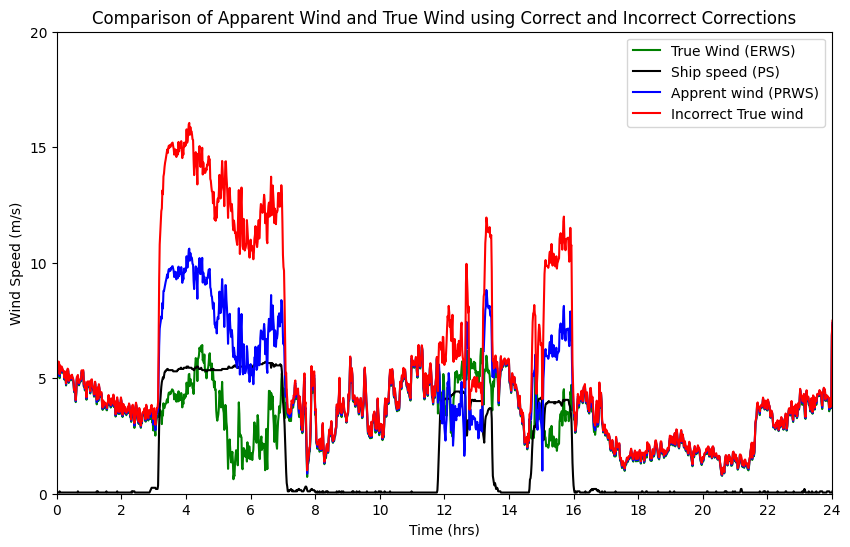

In [109]:
#Plotting the Platform Relative Wind Speed time series
plt.figure(figsize=(10,6))
plt.plot(time_hours, ERWS, label = "True Wind (ERWS)" , c = 'g')
plt.plot(time_hours, PS, label = 'Ship speed (PS)', c = 'k')
plt.plot(time_hours, PRWS, label = 'Apprent wind (PRWS)', c = 'b')
plt.plot (time_hours, ERWS_wrong, label = 'Incorrect True wind', c = 'r')
plt.legend()
plt.xlabel('Time (hrs)' )
plt.ylabel('Wind Speed (m/s)')
yticks = np.arange(0, 20+1,5)
xticks = np.arange(0, 24+1, 2)
plt.ylim(0,20)
plt.xlim(0,24)
plt.xticks(xticks)
plt.yticks(yticks)
plt.title("Comparison of Apparent Wind and True Wind using Correct and Incorrect Corrections")
plt.tight_layout